# **Analyse de conversations sur la santé mentale**
**Étudiant :** Emin Belkheir 22204589

**ETAPE 1 :**  Exploration d'un jeu de données

**Source des données :** https://www.kaggle.com/datasets/thedevastator/nlp-mental-health-conversations

**GitHub** https://github.com/cypnet/Analyse-de-conversations-sur-la-sant-mentale-

**Résumé:** L'objectif de l'étape 1 du projet est d'analyser

# Import des bibliothèques utilisées qui seront utilisées pour l'étape 1 :

**Pandas :** Manipuler des données sous forme de tableau

**NumPy :** Calcul mathématiques

**MatPlotLib :** Graphique afin de visualiser les données

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Les bibliothèques ont bien été importées.")

Les bibliothèques ont bien été importées.


In [31]:
path_data = "../../data/train.csv"
df = pd.read_csv(path_data)
print("Taille du fichier : ", df.shape)
print("Exemple de données : ", df.head(10))
print("Nom des colonnes : ", df.columns.tolist())


Taille du fichier :  (3512, 2)
Exemple de données :                                               Context  \
0  I'm going through some things with my feelings...   
1  I'm going through some things with my feelings...   
2  I'm going through some things with my feelings...   
3  I'm going through some things with my feelings...   
4  I'm going through some things with my feelings...   
5  I'm going through some things with my feelings...   
6  I'm going through some things with my feelings...   
7  I'm going through some things with my feelings...   
8  I'm going through some things with my feelings...   
9  I'm going through some things with my feelings...   

                                            Response  
0  If everyone thinks you're worthless, then mayb...  
1  Hello, and thank you for your question and see...  
2  First thing I'd suggest is getting the sleep y...  
3  Therapy is essential for those that are feelin...  
4  I first want to let you know that you are not ...  


In [32]:
# Nettoyage des données
# On peut voir qu'on a les mêmes questions avec plusieurs réponses différentes.
# On va supprimer les lignes vides et les données incomplètes.

df = df.dropna(how='all')
print("Taille du fichier après suppression des lignes vides : ", df.shape)

df = df.dropna(subset=['Context'])
print("Taille du fichier après suppression des lignes avec question vide : ", df.shape)

df = df.dropna(subset=['Response'])
df = df.reset_index(drop=True)  # Réinitialiser l'index après suppression
print("Taille du fichier après suppression des lignes avec réponse vide : ", df.shape)

Taille du fichier après suppression des lignes vides :  (3512, 2)
Taille du fichier après suppression des lignes avec question vide :  (3512, 2)
Taille du fichier après suppression des lignes avec réponse vide :  (3508, 2)


Nombre de questions de base :  3508
Nombre de réponses de base :  3508
Nombre de questions différentes :  995
Nombre de réponses différentes :  2479


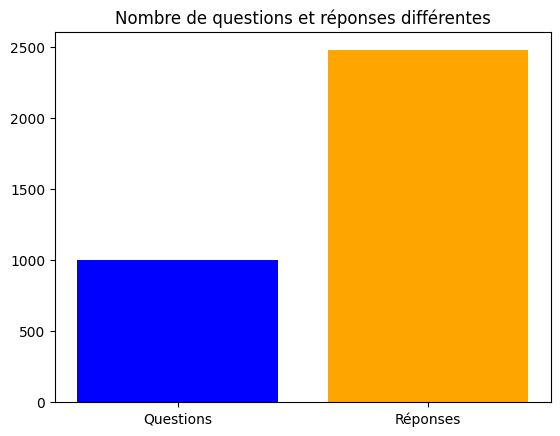

In [33]:
# Analyse du nombre de questions et réponses
# Compter le nombre total de questions et réponses
nb_questions_base = df['Context'].count()  # Nombre total de questions (valeurs non nulles)
nb_reponses_base = df['Response'].count()  # Nombre total de réponses (valeurs non nulles)
print("Nombre de questions de base : ", nb_questions_base)
print("Nombre de réponses de base : ", nb_reponses_base)

# Compter le nombre de questions et réponses uniques (sans doublons)
nb_questions = df['Context'].nunique()  # Nombre de questions différentes
nb_reponses = df['Response'].nunique()  # Nombre de réponses différentes
print("Nombre de questions différentes : ", nb_questions)
print("Nombre de réponses différentes : ", nb_reponses)

#Affichage du graphique pour le nombre de questions et réponses
labels = ['Questions', 'Réponses']
values = [nb_questions, nb_reponses]
plt.bar(labels, values, color=['blue', 'orange'])
plt.title('Nombre de questions et réponses différentes')
plt.show()


## Analyse de la distribution des réponses
Certaines questions reçoivent plus d'attention que d'autres. Nous allons calculer combien de réponses chaque question possède en moyenne.

Nombre maximum de réponses pour une seule question : 94
Nombre moyen de réponses par question : 3.53
Nombre median de réponses par question : 2.0
Ecart-type du nombre de réponses par question : 5.21
Question avec le plus de réponses : I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety. I have low self esteem but I’ve been happily married for almost 35 years.
   I’ve never had counseling about any of this. Do I have too many issues to address in counseling? (94 réponses)
Question avec le moins de réponses :  such as not enough sleep (1 réponse(s))


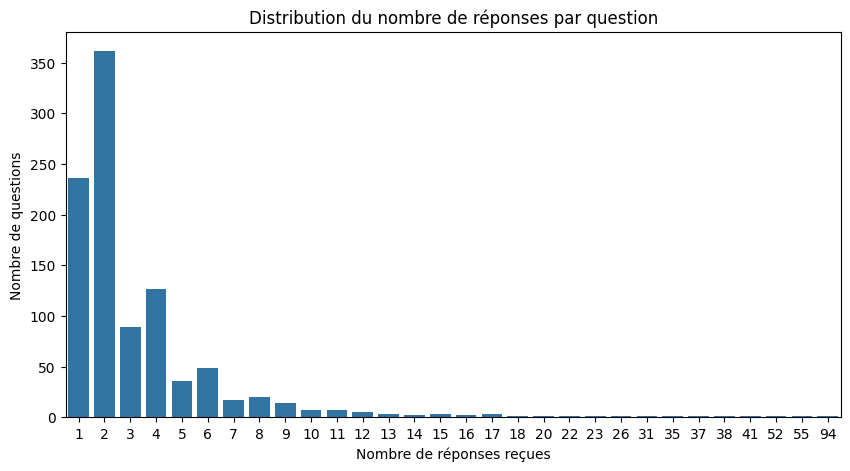

In [34]:
# On groupe par question et on compte le nombre de réponses
reponses_par_question = df.groupby('Context').count()['Response']

# Statistique descriptive
print(f"Nombre maximum de réponses pour une seule question : {reponses_par_question.max()}")
print(f"Nombre moyen de réponses par question : {reponses_par_question.mean():.2f}")
print(f"Nombre median de réponses par question : {reponses_par_question.median()}")
print(f"Ecart-type du nombre de réponses par question : {reponses_par_question.std():.2f}")

print(f"Question avec le plus de réponses : {reponses_par_question.idxmax()} ({reponses_par_question.max()} réponses)")
print(f"Question avec le moins de réponses : {reponses_par_question.idxmin()} ({reponses_par_question.min()} réponse(s))")

# Graphique de distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=reponses_par_question)
plt.title("Distribution du nombre de réponses par question")
plt.xlabel("Nombre de réponses reçues")
plt.ylabel("Nombre de questions")
plt.show()


## Tableau statistique récapitulatif
Résumé des statistiques principales du jeu de données.


In [35]:
# Calcul des statistiques
nb_patients = df['Context'].nunique()  # Nombre de patients uniques
nb_therapeutes = df['Response'].nunique()  # Nombre de réponses uniques (représentant les thérapeutes)
nb_conversations_total = len(df)  # Nombre total d'échanges
nb_echanges_moyen_par_conversation = df.groupby('Context').size().mean()

# DataFrame de statistiques
stats_data = {
    'Métrique': [
        'Nombre de patients (conversations uniques)',
        'Nombre de thérapeutes (réponses uniques)',
        'Nombre total d\'échanges',
        'Nombre moyen d\'échanges par conversation'
    ],
    'Valeur': [
        nb_patients,
        nb_therapeutes,
        nb_conversations_total,
        f"{nb_echanges_moyen_par_conversation:.2f}"
    ]
}

stats_df = pd.DataFrame(stats_data)

print("=" * 70)
print("TABLEAU STATISTIQUE RÉCAPITULATIF")
print("=" * 70)
print(stats_df.to_string(index=False))
print("=" * 70)


TABLEAU STATISTIQUE RÉCAPITULATIF
                                  Métrique Valeur
Nombre de patients (conversations uniques)    995
  Nombre de thérapeutes (réponses uniques)   2479
                   Nombre total d'échanges   3508
  Nombre moyen d'échanges par conversation   3.53


## Analyse des mots

On calcule le nombre de mots pour les questions (patients) et les réponses (thérapeutes).

Nombre de mots moyen (Patient) : 55.2
Nombre de mots moyen (Psy) : 177.2


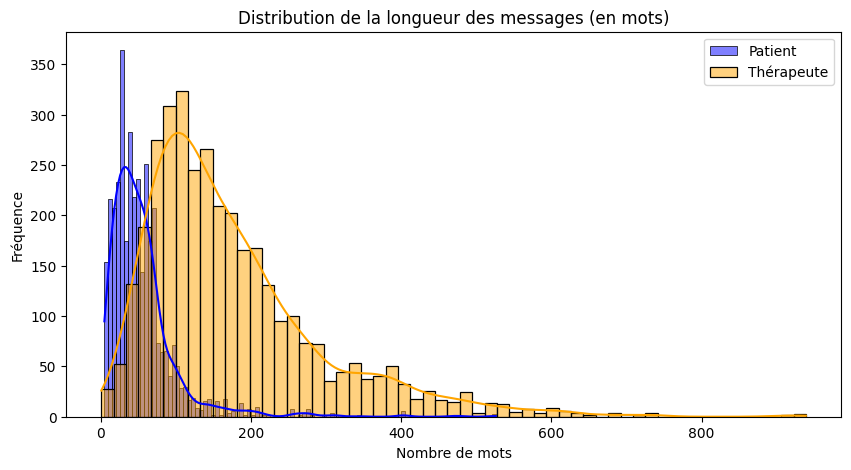

In [36]:
# Calcul du nombre de mots par message
df['words_context'] = df['Context'].str.split().str.len() #Transforme la chaine en liste de mot
df['words_response'] = df['Response'].str.split().str.len()

print(f"Nombre de mots moyen (Patient) : {df['words_context'].mean():.1f}")
print(f"Nombre de mots moyen (Psy) : {df['words_response'].mean():.1f}")

# Histogramme de comparaison
plt.figure(figsize=(10, 5))
sns.histplot(df['words_context'], color="blue", label="Patient", kde=True)
sns.histplot(df['words_response'], color="orange", label="Thérapeute", kde=True)
plt.title("Distribution de la longueur des messages (en mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## Nettoyage des phrases

Passage en minuscules et suppression de la ponctuation, des chiffres et des caractères spéciaux pour ne garder que les mots.

In [37]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = text.replace('\n', ' ')
    text = re.sub(r'[^a-z\s]', '', text)
    text = " ".join(text.split())
    return text

# Application du nettoyage sur les deux colonnes
df['Context_Clean'] = df['Context'].apply(clean_text)
df['Response_Clean'] = df['Response'].apply(clean_text)

# Comparaison avant vs après
print("AVANT :", df['Context'].iloc[0][:100], "...")
print("APRÈS :", df['Context_Clean'].iloc[0][:100], "...")

AVANT : I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think ...
APRÈS : im going through some things with my feelings and myself i barely sleep and i do nothing but think a ...


Suppression des mots fréquents mais sans valeur sémantique (mots de liaison) pour isoler les mots-clés du domaine de la santé mentale.

In [38]:
import nltk
from nltk.corpus import stopwords

#Liste officielle de Stopword de NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Fonction pour supprimer les stopwords d'un texte
def remove_stopwords(text):
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    return " ".join(filtered_words)

# Application sur le texte déjà nettoyé
df['Context_Final'] = df['Context_Clean'].apply(remove_stopwords)
df['Response_Final'] = df['Response_Clean'].apply(remove_stopwords)

# Comparaison
print("AVANT  :", df['Context_Clean'].iloc[0][:100])
print("APRÈS  :", df['Context_Final'].iloc[0][:100])

AVANT  : im going through some things with my feelings and myself i barely sleep and i do nothing but think a
APRÈS  : im going things feelings barely sleep nothing think im worthless shouldnt ive never tried contemplat


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sopar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Méthode 1 : Identification par lexique et fréquences

Nous allons extraire les mots les plus fréquents (après nettoyage) pour identifier les thématiques majeures abordées par les patients et les réponses apportées par les psys.

In [46]:
# 1. On transforme le texte token
s_patients = pd.Series(" ".join(df['Context_Final']).split())
s_psys = pd.Series(" ".join(df['Response_Final']).split())

# 2. On compte les occurrences et on garde le top 20
top_p = s_patients.value_counts().head(20)
top_psy = s_psys.value_counts().head(20)

# 3. On crée le tableau de comparaison
df_lexique = pd.DataFrame({
    'Mots Patients': top_p.index,
    'Fréq. Patient': top_p.values,
    'Mots Psys': top_psy.index,
    'Fréq. Psy': top_psy.values
})

df_lexique['Freq/Conv'] = (df_lexique['Fréq. Patient'] + df_lexique['Fréq. Psy']) / len(df)

print("=" * 60)
print("LEXIQUE - TOP 20")
print("=" * 60)
print(df_lexique)
print("=" * 60)
print(df_lexique[['Mots Patients', 'Fréq. Patient', 'Freq/Conv']].head(10))

LEXIQUE - TOP 20
   Mots Patients  Fréq. Patient     Mots Psys  Fréq. Psy  Freq/Conv
0             im           2162           may       2900   1.442987
1           feel           1223          feel       2689   1.115165
2           dont           1186         would       2353   1.008837
3           like           1150          help       2286   0.979475
4           know            973          like       2240   0.915906
5            get            901  relationship       1907   0.800456
6            ive            862          time       1885   0.783067
7           want            768        people       1765   0.722064
8          years            669     therapist       1666   0.665621
9           time            627          know       1581   0.629418
10         never            621           way       1570   0.624572
11        always            509           one       1558   0.589225
12        really            507          want       1529   0.580388
13  relationship            500

## Les Bigrammes



In [40]:
from sklearn.feature_extraction.text import CountVectorizer

# Extraction des groupes de 2 mots les plus fréquents
vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(df['Context_Final'])
bag_of_words = vec.transform(df['Context_Final'])
sum_words = bag_of_words.sum(axis=0)

words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

print("--- TOP 10 BIGRAMMES (PATIENTS) ---")
for word, freq in words_freq[:10]:
    print(f"{word}: {freq}")

--- TOP 10 BIGRAMMES (PATIENTS) ---
dont know: 486
feel like: 378
issues address: 188
dont want: 170
married years: 127
like im: 114
years ive: 110
self esteem: 105
history sexual: 100
sexual abuse: 100


In [41]:
# 1. Nombre de conversations par thérapeute 
distrib_therapeute = df['Response'].value_counts()
print(f"Nombre de conversations par thérapeute (Top 5) :\n{distrib_therapeute.head(5)}\n")

# 2. Identification des sujets via un lexique choisi 
lexique_choisi = {
    'stress': ['stress', 'work', 'busy', 'pressure'],
    'anxiety': ['anxious', 'anxiety', 'panic', 'fear'],
    'depression': ['sad', 'depressed', 'hopeless', 'suicide'],
    'sleep': ['sleep', 'insomnia', 'night', 'tired']
}

def identify_subjects(text):
    # On vérifie si un des mots-clés du lexique est dans le texte
    found = [topic for topic, words in lexique_choisi.items() if any(w in str(text) for w in words)]
    return found if found else ['autre']

df['Sujet_Lexique'] = df['Context_Final'].apply(identify_subjects)

print("--- EXEMPLE D'IDENTIFICATION PAR LEXIQUE ---")
print(df[['Context_Final', 'Sujet_Lexique']].head())

Nombre de conversations par thérapeute (Top 5) :
Response
The fact that you're reaching out for help here is really helpful.The first thing I would suggest is that you consider seeing a local mental health professional yourself to be able to talk about the details, how this is affecting you, and how you can hold onto you are while also being supportive to you husband.From the way that you describe this, I wonder what has changed since coming home from the hospital. Perhaps you can have a conversation with your husband this and mention that you are asking him questions to learn more about his experience and you can discuss how you notice that things were going much better when he came home from the hospital, and now things are not as good. Perhaps he can tell you about what is different so that you may know him would be most helpful to him.I also hope that you husband is still continuing with his own treatment.There may also be a local peer support telephone number for the county that y

## Méthode 2 : Clusters via vecteurs TF-IDF

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

#Vectorisation TF-IDF
tfidf_vec = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vec.fit_transform(df['Context_Final'])

#Clustering K-Means
km_tfidf = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_TFIDF'] = km_tfidf.fit_predict(X_tfidf)

#Affichage des mots-clés par cluster
print("--- RÉSULTATS MÉTHODE 2 (TF-IDF) ---")
order_centroids = km_tfidf.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vec.get_feature_names_out()

for i in range(5):
    print(f"Cluster {i}: ", end='')
    for ind in order_centroids[i, :6]:
        print(f'{terms[ind]} ', end='')
    print()

--- RÉSULTATS MÉTHODE 2 (TF-IDF) ---
Cluster 0: years told sex time back child 
Cluster 1: im dont feel know like want 
Cluster 2: therapy normal still shaky everytime cry 
Cluster 3: decide client counselor end terminate working 
Cluster 4: counseling address history many issues process 


## Méthode 3 : Clusters via Word Embeddings

In [49]:
## Méthode 3 : Clusters via Word Embeddings
import spacy
import numpy as np
from sklearn.cluster import KMeans
from collections import Counter

# 1. Chargement du modèle (on utilise 'sm' car c'est le plus léger)
try:
    nlp_vec = spacy.load("en_core_web_sm")
except:
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp_vec = spacy.load("en_core_web_sm")

# 2. Extraction des vecteurs moyens par phrase
# On s'assure que nlp_vec est utilisé ici
df['Vectors'] = df['Context_Final'].apply(lambda x: nlp_vec(x).vector)
X_emb = np.stack(df['Vectors'].values)

# 3. Clustering sur les vecteurs
km_emb = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_Embeddings'] = km_emb.fit_predict(X_emb)

print("--- MÉTHODE 3 (EMBEDDINGS) TERMINÉE ---")
print("--- RÉSULTATS MÉTHODE 3 (EMBEDDINGS) ---")
# Pour chaque cluster, on cherche les mots les plus fréquents dans ce groupe
for i in range(5):
    cluster_texts = df[df['Cluster_Embeddings'] == i]['Context_Final']
    words = " ".join(cluster_texts).split()
    most_common = Counter(words).most_common(6)
    print(f"Cluster {i} (Sémantique): {[w[0] for w in most_common]}")

--- MÉTHODE 3 (EMBEDDINGS) TERMINÉE ---
--- RÉSULTATS MÉTHODE 3 (EMBEDDINGS) ---
Cluster 0 (Sémantique): ['counseling', 'therapist', 'know', 'end', 'client', 'counselor']
Cluster 1 (Sémantique): ['dont', 'im', 'like', 'feel', 'know', 'want']
Cluster 2 (Sémantique): ['counseling', 'really', 'anything', 'help', 'people', 'something']
Cluster 3 (Sémantique): ['im', 'ive', 'like', 'feel', 'get', 'many']
Cluster 4 (Sémantique): ['feel', 'years', 'time', 'im', 'like', 'relationship']


## Méthode 4 : Extraction de sujets via LDA

In [50]:
from sklearn.decomposition import LatentDirichletAllocation

# 1. Création et entraînement du modèle LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_tfidf)

# 2. Affichage des thèmes LDA
print("--- RÉSULTATS MÉTHODE 4 (LDA) ---")
for i, topic in enumerate(lda.components_):
    print(f"Thème {i}: ", end='')
    print([terms[ind] for ind in topic.argsort()[-6:]])

--- RÉSULTATS MÉTHODE 4 (LDA) ---
Thème 0: ['people', 'like', 'counseling', 'dont', 'feel', 'im']
Thème 1: ['sex', 'get', 'people', 'still', 'normal', 'therapy']
Thème 2: ['sometimes', 'right', 'told', 'see', 'know', 'therapist']
Thème 3: ['issues', 'counseling', 'many', 'address', 'im', 'history']
Thème 4: ['years', 'get', 'feel', 'dont', 'like', 'im']


## ** COMPARAISON DES 4 METHDOES ** ##


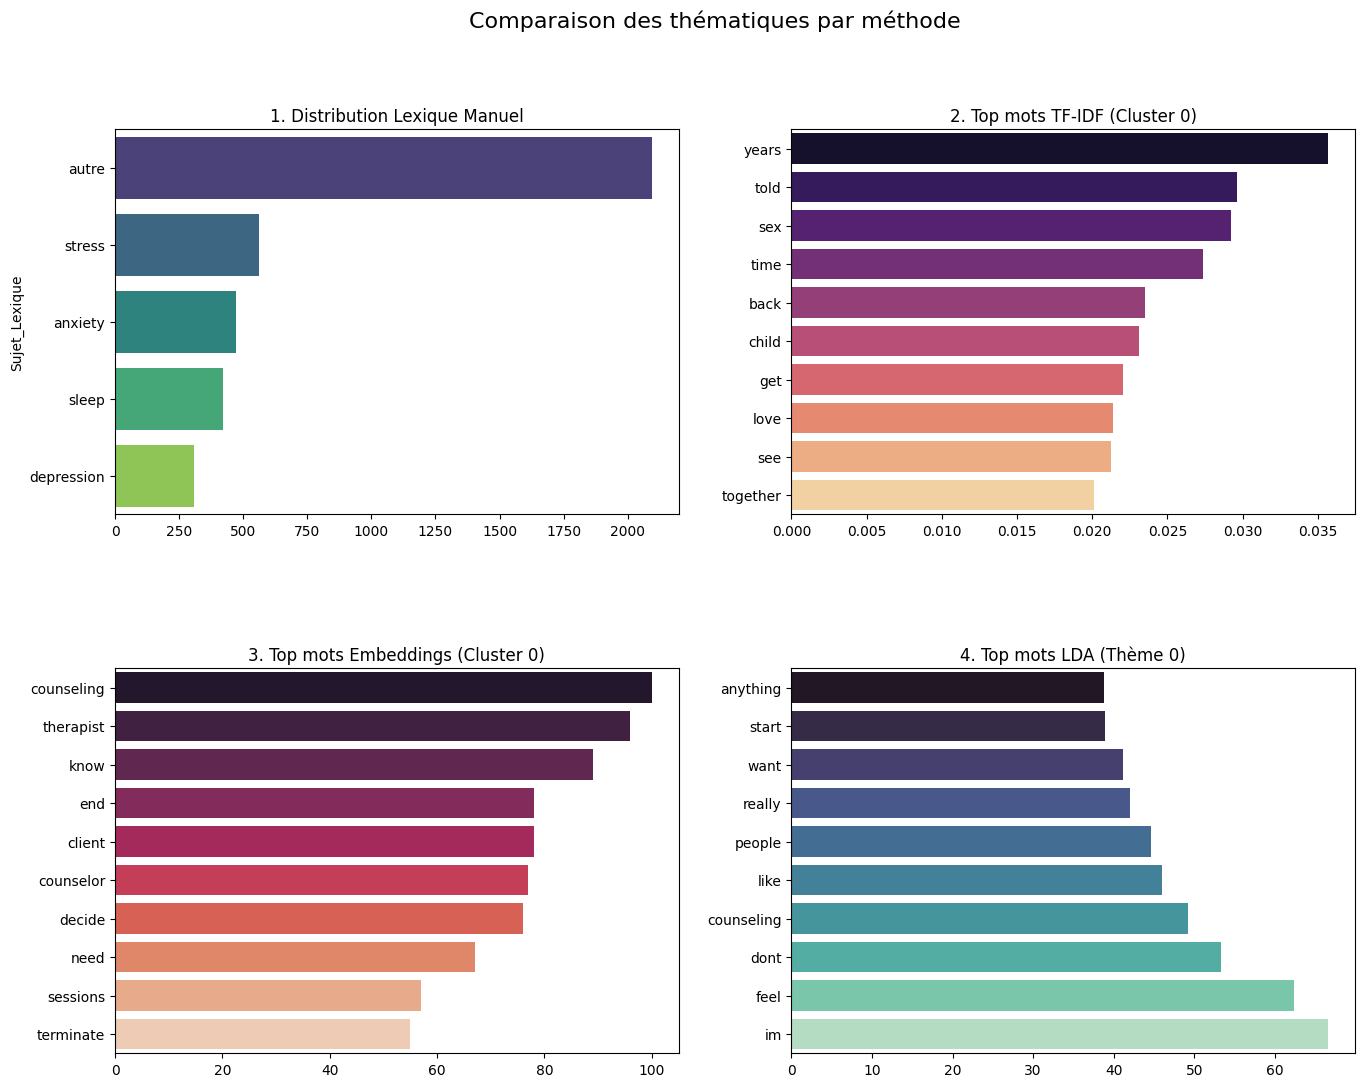

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configuration de la grille
plt.figure(figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

# 1. GRAPH LEXIQUE
plt.subplot(2, 2, 1)
lexique_series = df['Sujet_Lexique'].explode().value_counts()
sns.barplot(x=lexique_series.values, y=lexique_series.index, hue=lexique_series.index, palette='viridis', legend=False)
plt.title("1. Distribution Lexique Manuel")

# 2. GRAPH TF-IDF (Mots du Cluster 0)
plt.subplot(2, 2, 2)
# On recalcule les centroïdes avec le bon nom : km_tfidf
centroids_tfidf = km_tfidf.cluster_centers_.argsort()[:, ::-1]
words_tfidf = [terms[i] for i in centroids_tfidf[0, :10]]
weights_tfidf = [km_tfidf.cluster_centers_[0, i] for i in centroids_tfidf[0, :10]]
sns.barplot(x=weights_tfidf, y=words_tfidf, hue=words_tfidf, palette='magma', legend=False)
plt.title("2. Top mots TF-IDF (Cluster 0)")

# 3. GRAPH EMBEDDINGS (Mots du Cluster 0)
plt.subplot(2, 2, 3)
emb_counts = Counter(" ".join(df[df['Cluster_Embeddings'] == 0]['Context_Final']).split()).most_common(10)
sns.barplot(x=[w[1] for w in emb_counts], y=[w[0] for w in emb_counts], hue=[w[0] for w in emb_counts], palette='rocket', legend=False)
plt.title("3. Top mots Embeddings (Cluster 0)")

# 4. GRAPH LDA (Mots du Thème 0)
plt.subplot(2, 2, 4)
# On utilise le nom lda défini dans ta méthode 4
topic0_lda = lda.components_[0].argsort()[-10:]
words_lda = [terms[i] for i in topic0_lda]
weights_lda = [lda.components_[0, i] for i in topic0_lda]
sns.barplot(x=weights_lda, y=words_lda, hue=words_lda, palette='mako', legend=False)
plt.title("4. Top mots LDA (Thème 0)")

plt.suptitle("Comparaison des thématiques par méthode", fontsize=16)
plt.show()